In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import tkinter as tk
from tkinter import filedialog
import seaborn as sns
import matplotlib.pyplot as plt

from Demos.win32cred_demo import target
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import figure

root = tk.Tk()
root.withdraw()           # ছোট উইন্ডো লুকিয়ে রাখে

file_path = filedialog.askopenfilename(
    title="heart.csv ফাইল সিলেক্ট করুন",
    filetypes=[("CSV files", "*.csv")]
)

if file_path:
    df = pd.read_csv(file_path)
    display(df.head(10))     # Jupyter-এ সুন্দর করে দেখাবে
else:
    print("কোনো ফাইল বেছে নেওয়া হয়নি")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [16]:
print("Info:")
df.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [17]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [18]:
target_col = "HeartDisease"
numeric_cols=["Age", "RestingBP","Cholesterol","FastingBS","MaxHR","Oldpeak",]
categorical_cols = ["Sex", "ChestPainType", "RestingECG",
                    "ExerciseAngina", "ST_Slope"]

print(target_col)
print(numeric_cols)
print(categorical_cols)



HeartDisease
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [19]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [20]:
df[numeric_cols].agg(["min","max","mean","median","std"]).T

,min,max,mean,median,std
Age,28.0,77.0,53.510893,54.0,9.432617
RestingBP,0.0,200.0,132.396514,130.0,18.514154
Cholesterol,0.0,603.0,198.799564,223.0,109.384145
FastingBS,0.0,1.0,0.233115,0.0,0.423046
MaxHR,60.0,202.0,136.809368,138.0,25.460334
Oldpeak,-2.6,6.2,0.887364,0.6,1.066570


In [21]:
for c in categorical_cols:
     print(c, df[c].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


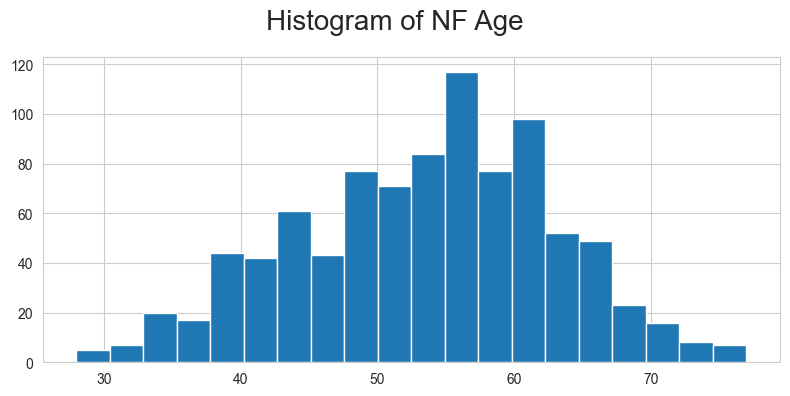

In [22]:
import matplotlib.pyplot as plt

df["Age"].hist(bins=20, figsize=(8,4))
plt.suptitle("Histogram of NF Age", fontsize=20)
plt.tight_layout()
plt.show()

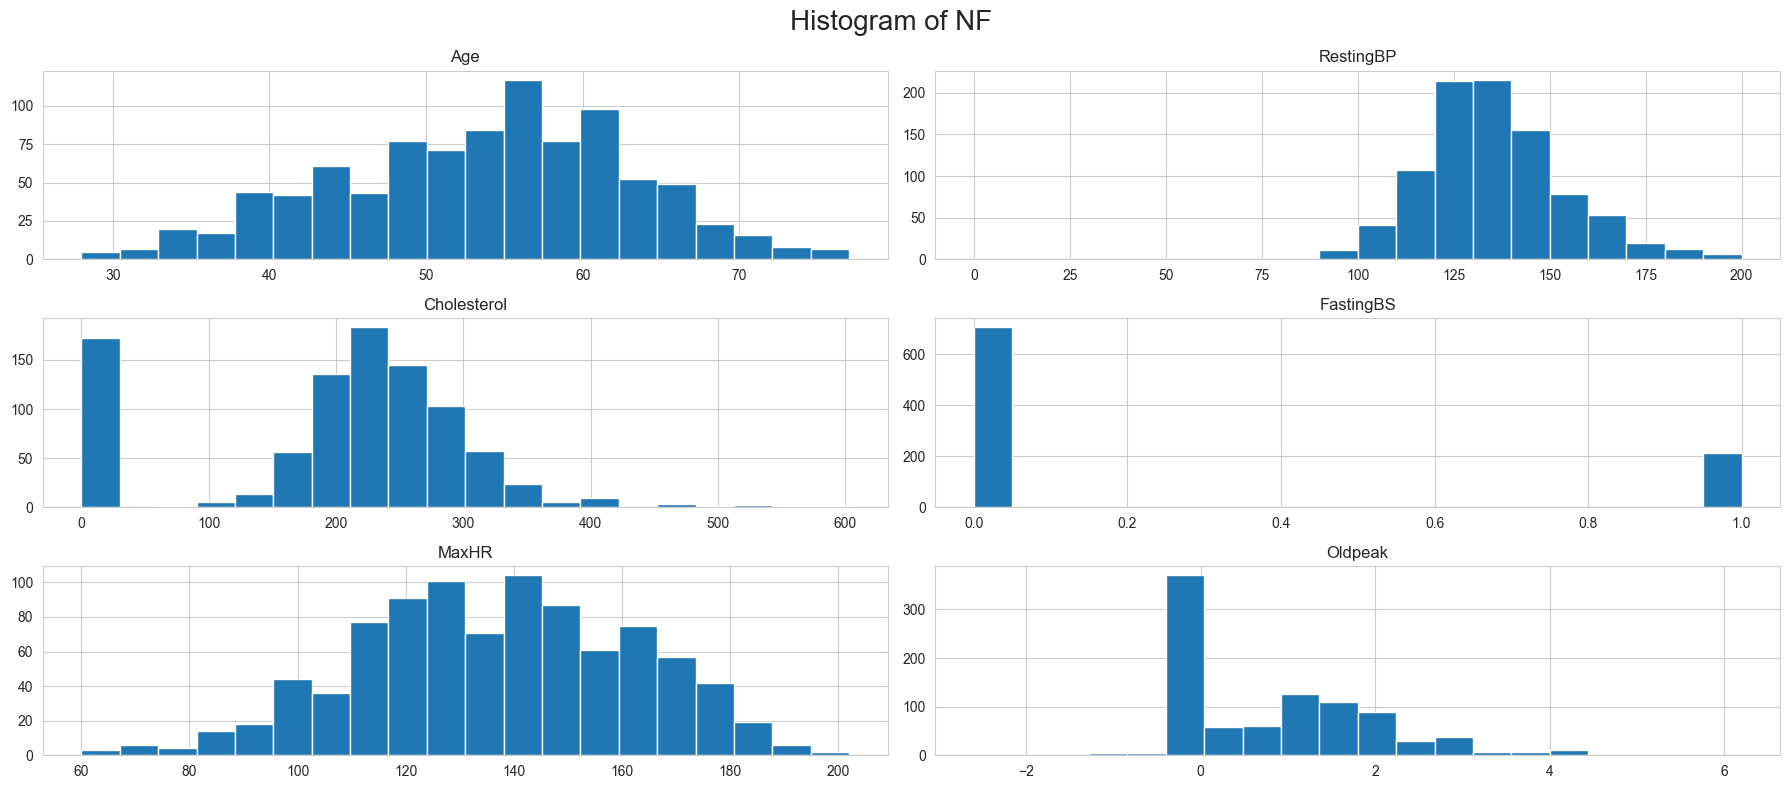

In [23]:

df[numeric_cols].hist(bins=20, figsize=(18,8))
plt.suptitle("Histogram of NF ", fontsize=20)
plt.tight_layout()
plt.show()

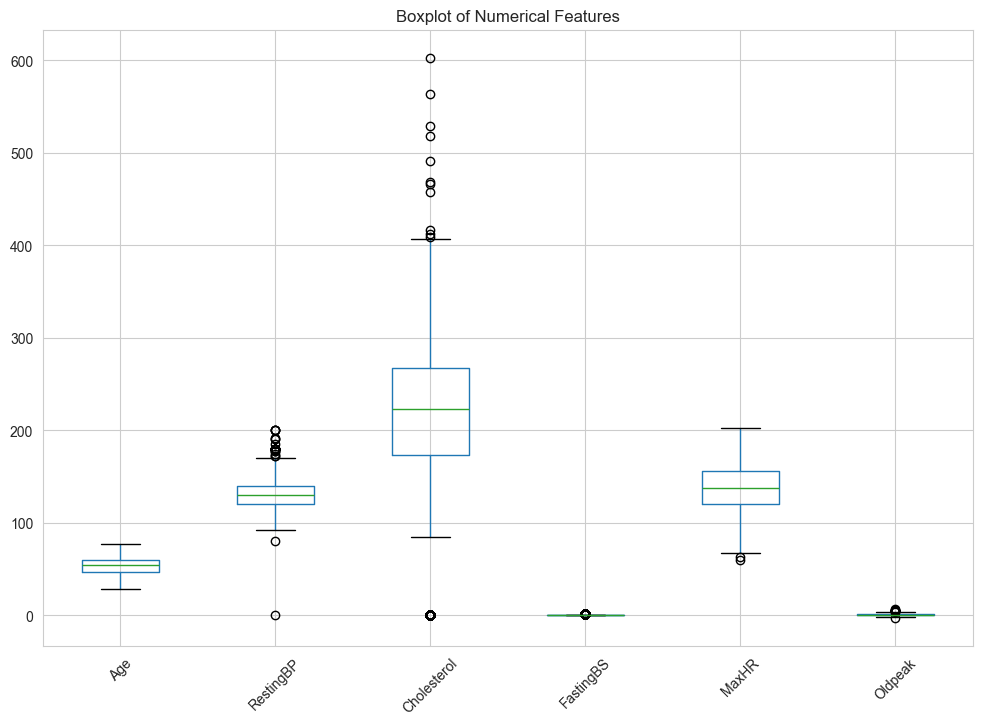

In [24]:
# Boxplots to get a sense of spread and possible outliers
plt.figure(figsize=(12,8))
df[numeric_cols].boxplot()
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

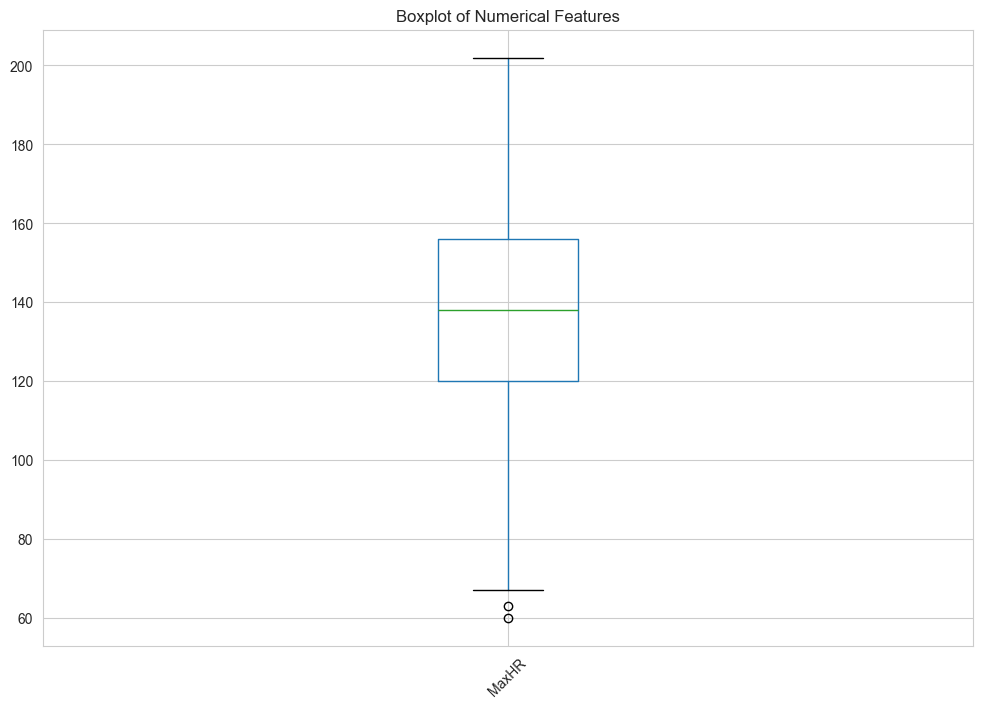

In [25]:
# Boxplots to get a sense of spread and possible outliers
plt.figure(figsize=(12,8))
df.boxplot(column=numeric_cols[4])
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

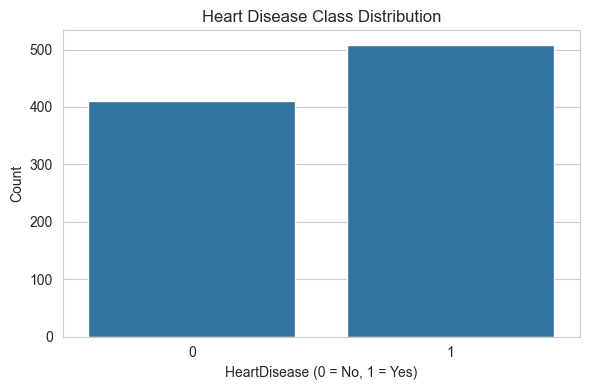

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['HeartDisease'])  # ← সরাসরি নাম দিন
plt.title("Heart Disease Class Distribution")
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [27]:
df[target_col].value_counts(normalize=True)

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

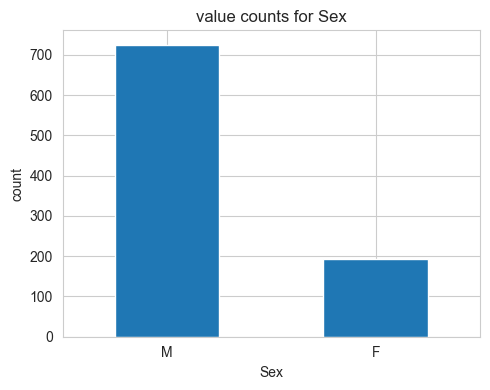

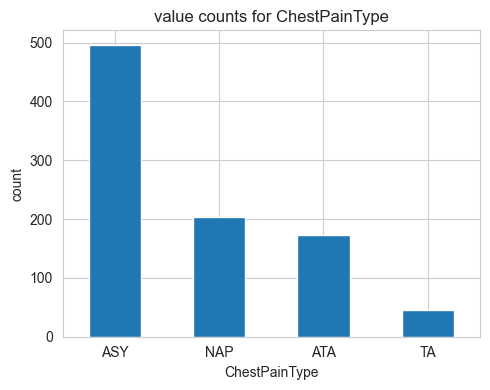

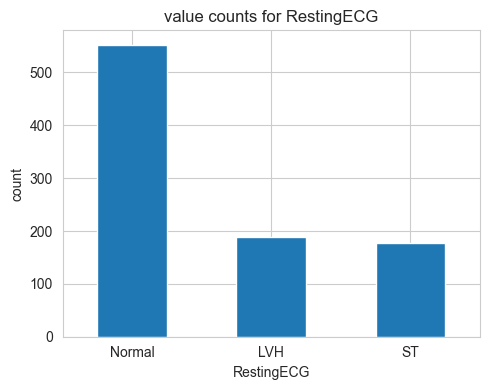

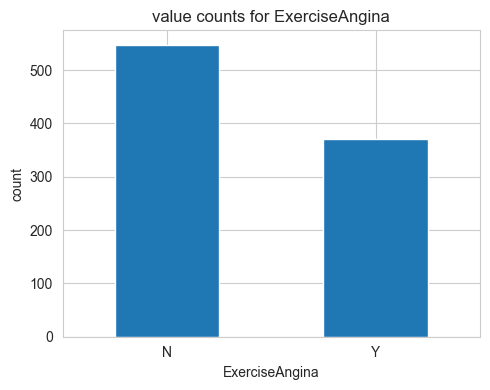

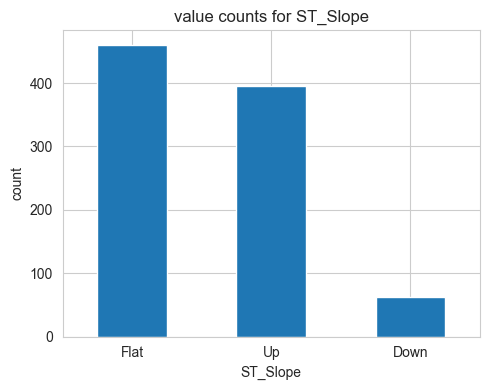

In [29]:
for c in categorical_cols:
    plt.figure(figsize=(5,4))
    df[c].value_counts().plot(kind="bar")
    plt.title(f"value counts for {c}")
    plt.ylabel("count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


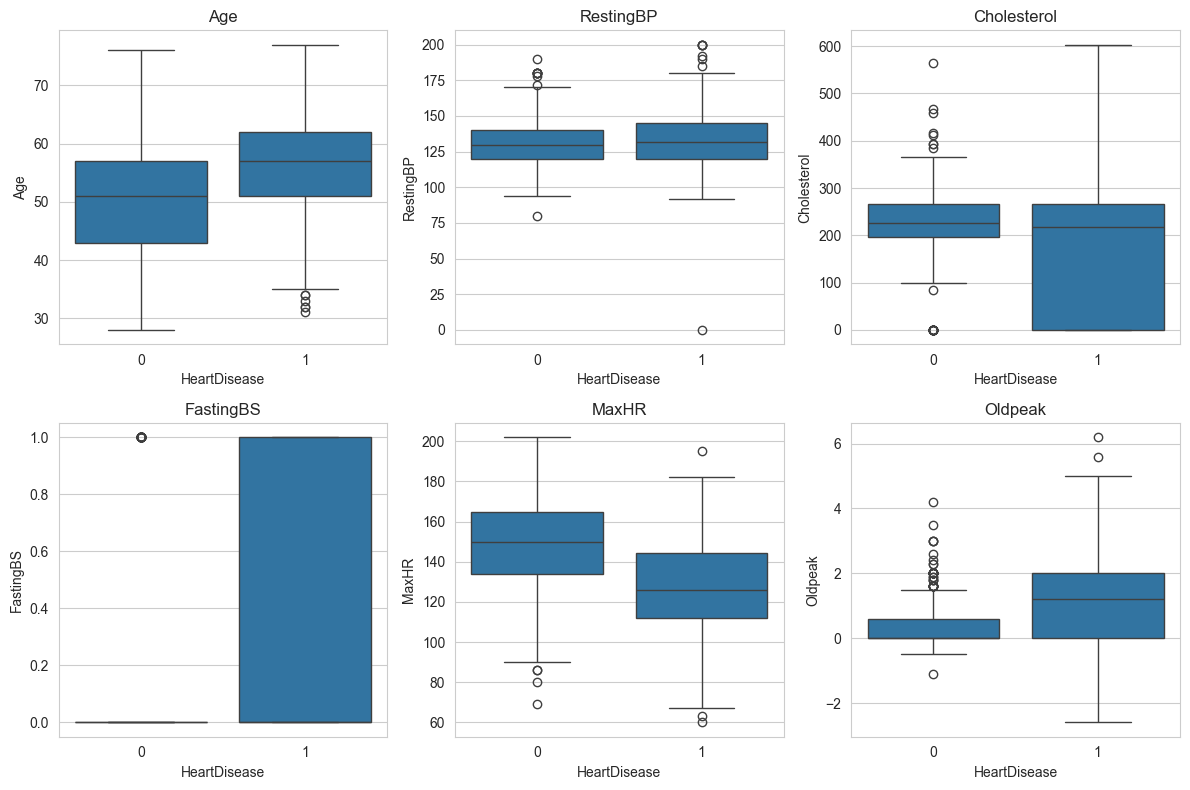

In [30]:
# Boxplots of numeric features split by HeartDisease
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols,1):
  plt.subplot(2,3,i)
  sns.boxplot(x=df[target_col], y = df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

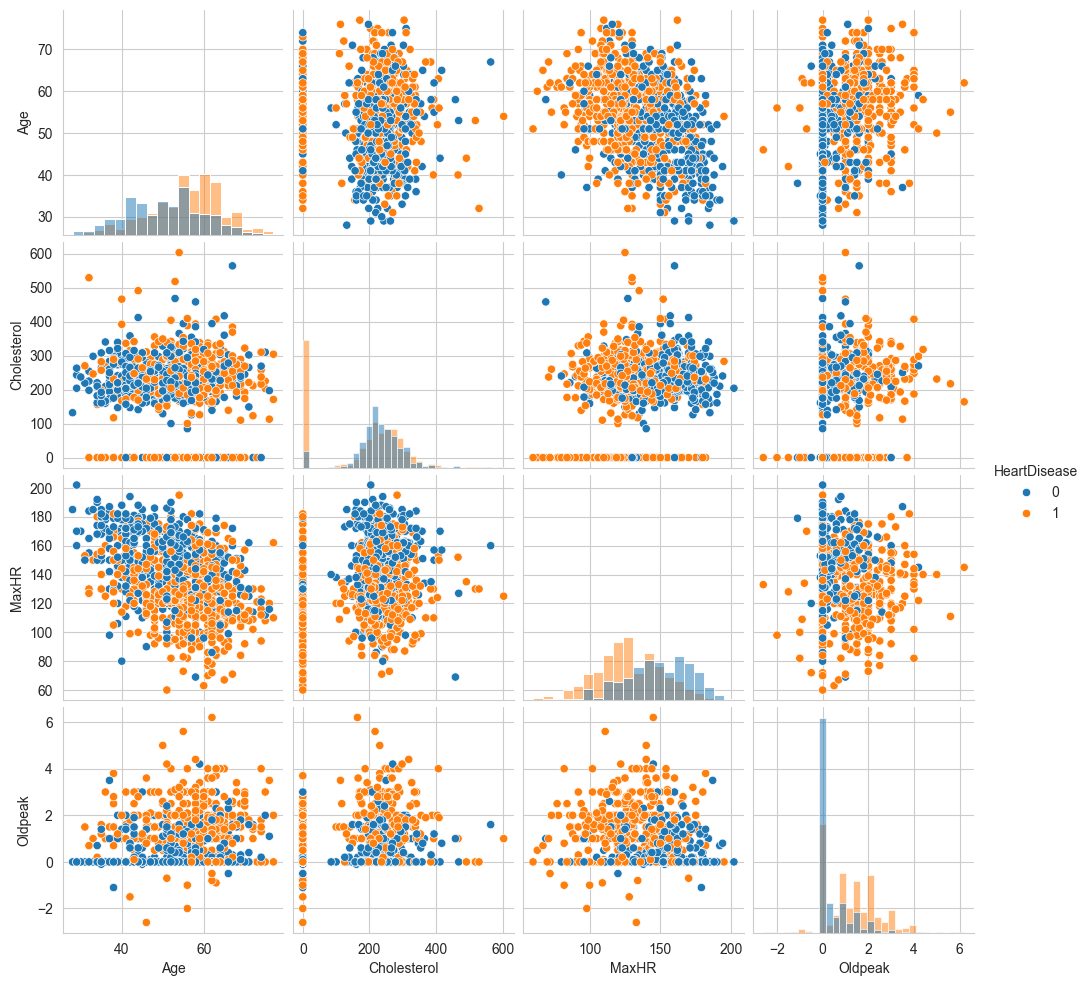

In [31]:
#Pairplot for a Subset of Features
sns.pairplot(df[["Age","Cholesterol","MaxHR", "Oldpeak", "HeartDisease"]],hue="HeartDisease", diag_kind="hist")
plt.show()

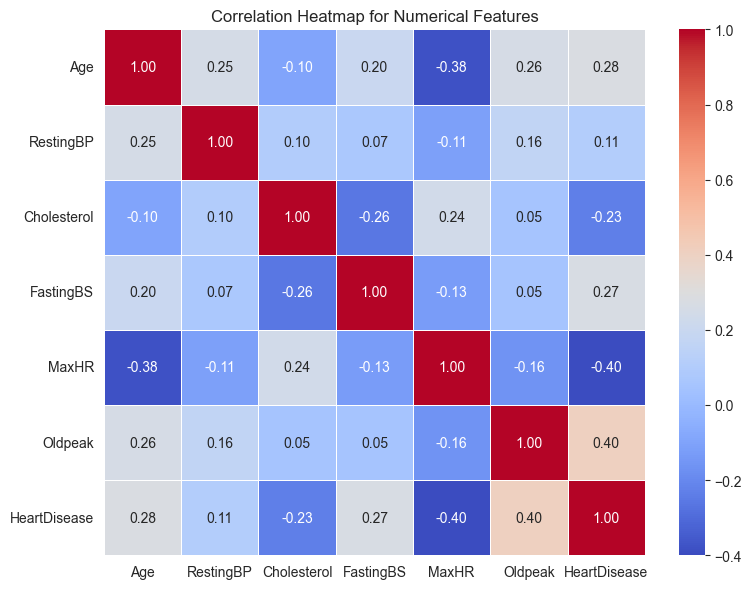

In [32]:
#Correlation Matrix and Heatmap
corr_matrix = df[numeric_cols + [target_col]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

In [33]:
corr_matrix[target_col].sort_values(ascending=False)

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64


Proportion of HeartDisease within Sex


HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


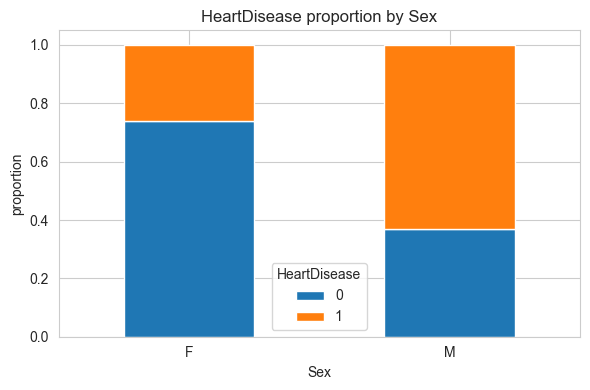


Proportion of HeartDisease within ChestPainType


HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


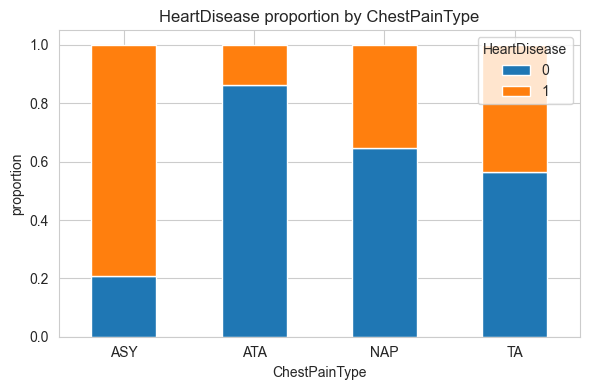


Proportion of HeartDisease within RestingECG


HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


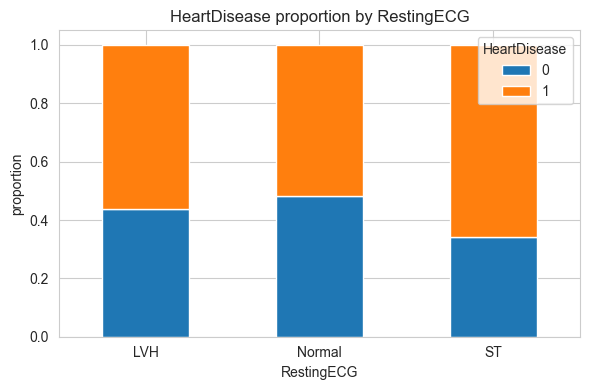


Proportion of HeartDisease within ExerciseAngina


HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


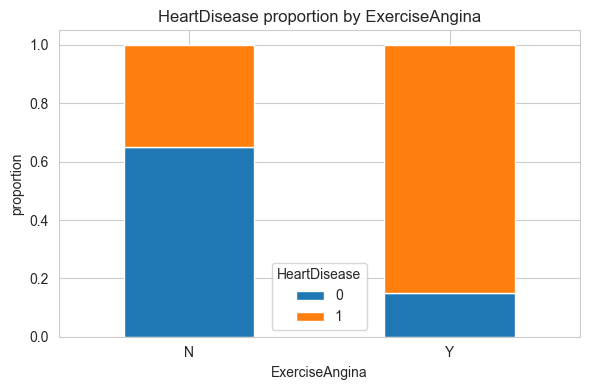


Proportion of HeartDisease within ST_Slope


HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


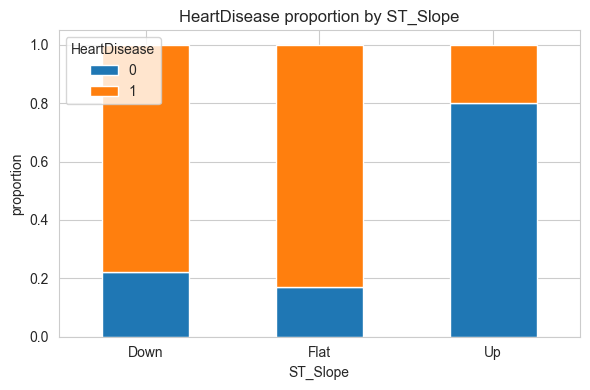

In [34]:
#Categorical Features vs Target
for c in categorical_cols:
  ct = pd.crosstab(df[c], df[target_col], normalize="index")
  print(f"\nProportion of HeartDisease within {c}")
  display(ct)

  ct.plot(kind="bar", stacked=True, figsize=(6,4))
  plt.title(f"HeartDisease proportion by {c}")
  plt.ylabel("proportion")
  plt.xticks(rotation=0)
  plt.tight_layout()
  plt.show()